# Chapter 1: Understanding the data.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Set the visualization style for professional-looking plots
sns.set_theme(style="whitegrid")

## Loading and cleaning the data

In [13]:
# Load the data, explicitly treating '#n/a' strings as missing values (NaN)
df = pd.read_csv('../.data/A21_90213.csv', na_values=['#n/a'])

# Convert the 'date_time' column from text to actual datetime objects
df['date_time'] = pd.to_datetime(df['date_time'])

# Extract 'Month' and 'Year' for seasonal and historical analysis
df['Month'] = df['date_time'].dt.month
df['Year'] = df['date_time'].dt.year

# Define the key variables relevant to the eutrophication problem
key_columns = {
    'NO3_NO2_N_Diss_Water': 'Nitrates (mg/L)',
    'PO4_P_Diss_Water': 'Phosphates (mg/L)',
    'pH_Diss_Water': 'pH Level',
    'EC_Phys_Water': 'Electrical Conductivity'
}

# Convert selected columns to numeric, coercing any remaining weird text to NaN
for col in key_columns.keys():
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Display the shape and the first few rows to verify the cleaning process
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df[['date_time', 'Month', 'Year'] + list(key_columns.keys())].head()

Dataset loaded with 317 rows and 43 columns.


,date_time,Month,Year,NO3_NO2_N_Diss_Water,PO4_P_Diss_Water,pH_Diss_Water,EC_Phys_Water
0,1962-06-19 06:00:00,6,1962,18.30,NaN,7.5,61.1
1,1962-07-17 06:00:00,7,1962,16.04,NaN,7.2,61.1
2,1962-08-21 06:00:00,8,1962,20.33,NaN,8.2,70.0
3,1962-09-18 06:00:00,9,1962,18.98,NaN,8.1,66.7
4,1962-10-19 06:00:00,10,1962,15.36,NaN,7.2,66.7


## Historical long-term trends

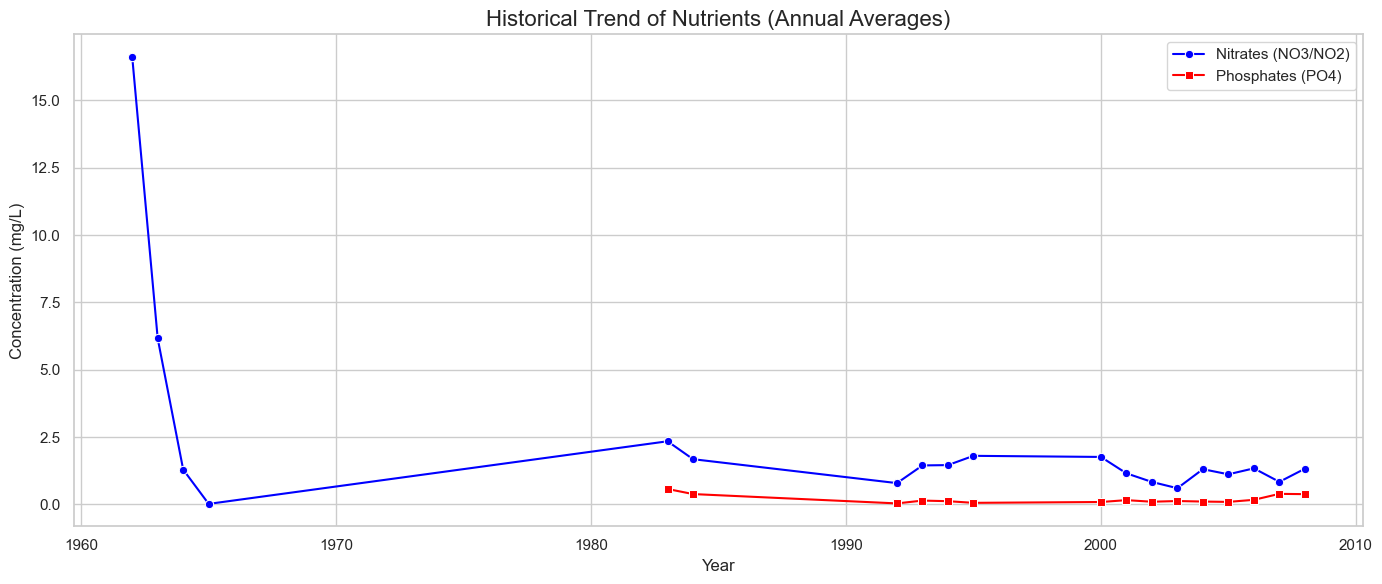

In [14]:
# Group data by year to get annual averages, reducing daily/monthly noise
df_yearly = df.groupby('Year')[['NO3_NO2_N_Diss_Water', 'PO4_P_Diss_Water']].mean().reset_index()

plt.figure(figsize=(14, 6))

# Plot annual average for Nitrates
sns.lineplot(data=df_yearly, x='Year', y='NO3_NO2_N_Diss_Water', 
             label='Nitrates (NO3/NO2)', color='blue', marker='o')

# Plot annual average for Phosphates
sns.lineplot(data=df_yearly, x='Year', y='PO4_P_Diss_Water', 
             label='Phosphates (PO4)', color='red', marker='s')

plt.title('Historical Trend of Nutrients (Annual Averages)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Concentration (mg/L)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Conclusion: There is a massive, structural spike in Nitrate pollution starting around the year 2000. While Phosphates remain relatively low, the drastic increase in Nitrates indicates a major systemic change (like a new wastewater source or intensified agriculture) that is driving the severe eutrophication in the dam.

## Seasonality analysis (root cause investigation)

C:\Users\Femke\AppData\Local\Temp\ipykernel_9136\2971186337.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Month', y='NO3_NO2_N_Diss_Water', palette='viridis')


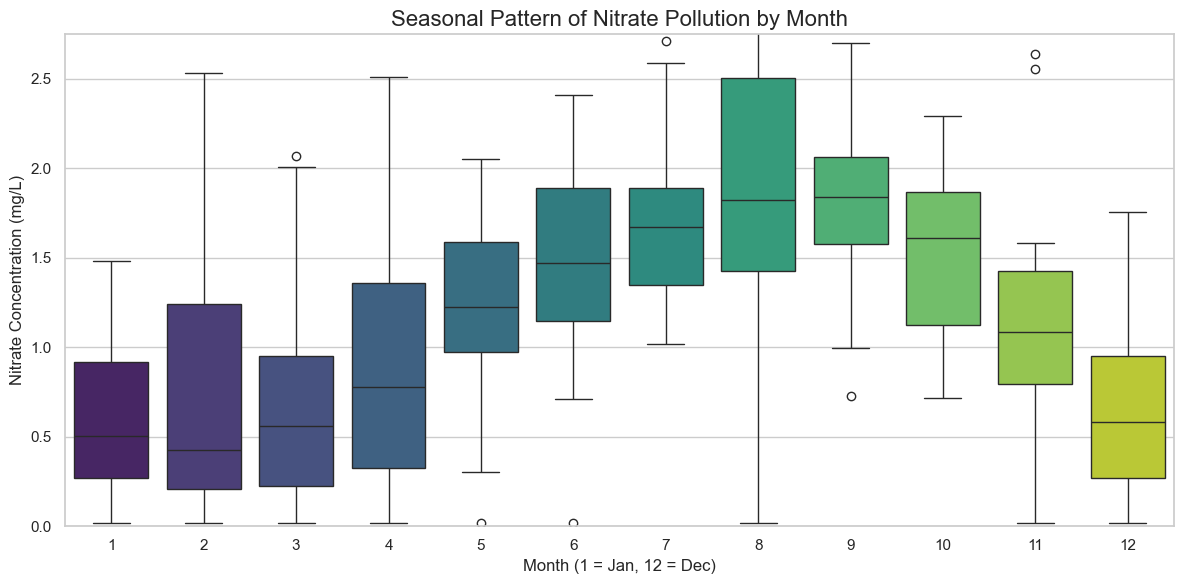

In [15]:
plt.figure(figsize=(12, 6))
    
# Use a boxplot to see the distribution of Nitrates per month
sns.boxplot(data=df, x='Month', y='NO3_NO2_N_Diss_Water', palette='viridis')

plt.title('Seasonal Pattern of Nitrate Pollution by Month', fontsize=16)
plt.xlabel('Month (1 = Jan, 12 = Dec)', fontsize=12)
plt.ylabel('Nitrate Concentration (mg/L)', fontsize=12)

# Limit the y-axis to the 95th percentile to hide extreme outliers and focus on the main data
y_max = df['NO3_NO2_N_Diss_Water'].quantile(0.95)
if pd.notna(y_max):
    plt.ylim(0, y_max)
    
plt.tight_layout()
plt.show()

Conclusion: Nitrate levels consistently peak between June and October (the South African dry winter and early spring). This suggests that lower water volumes concentrate the pollutants, and that the first rains after the dry season might be washing accumulated agricultural fertilizers into the dam.

## Correlation matrix heatmap

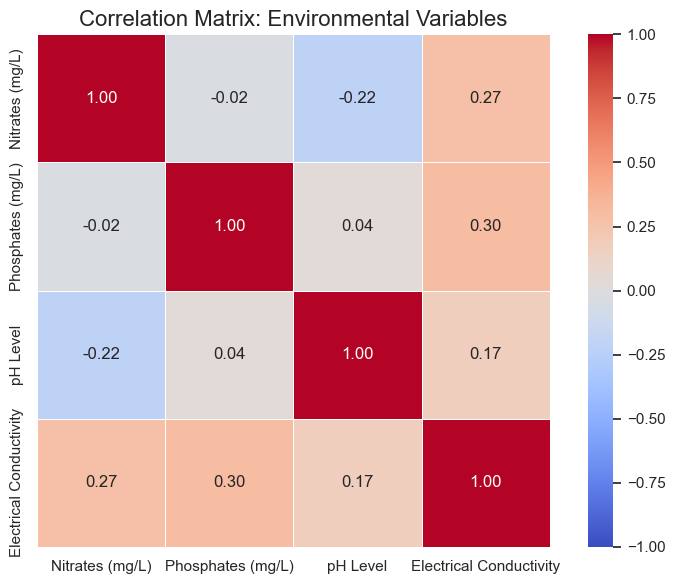

In [16]:
# Rename columns for a cleaner, readable heatmap
df_heatmap = df[list(key_columns.keys())].rename(columns=key_columns)

# Calculate the Pearson correlation matrix
corr_matrix = df_heatmap.corr()

plt.figure(figsize=(8, 6))

# Generate a heatmap with annotations
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            center=0, square=True, fmt=".2f", linewidths=.5)

plt.title('Correlation Matrix: Environmental Variables', fontsize=16)
plt.tight_layout()
plt.show()

Conclusion: There is a positive correlation between Nitrates and Electrical Conductivity (EC). This confirms that EC is a reliable proxy for nutrient pollution; as general pollution and dissolved salts increase, nitrate loading increases simultaneously.

## Cause & effect

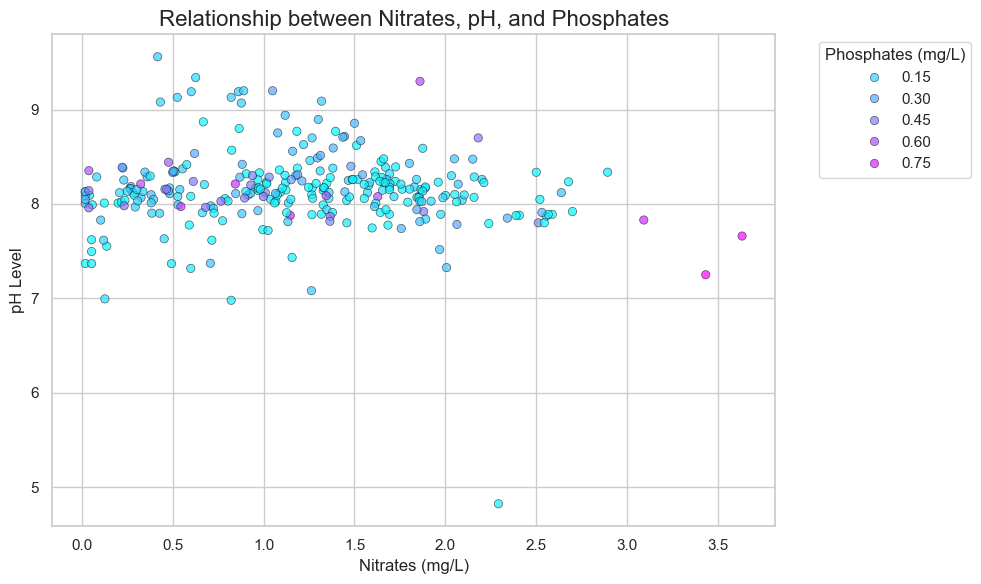

In [17]:
# Often, high nutrient levels cause algal blooms, which consume CO2 and alter the pH level.
plt.figure(figsize=(10, 6))

# Plot Nitrates vs pH, colored by the amount of Phosphates
sns.scatterplot(data=df, x='NO3_NO2_N_Diss_Water', y='pH_Diss_Water', 
                hue='PO4_P_Diss_Water', palette='cool', alpha=0.7, edgecolor='k')

plt.title('Relationship between Nitrates, pH, and Phosphates', fontsize=16)
plt.xlabel('Nitrates (mg/L)', fontsize=12)
plt.ylabel('pH Level', fontsize=12)

# Enhance the legend
plt.legend(title='Phosphates (mg/L)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Conclusion: The water is highly alkaline, with pH levels mostly clustered between 7.5 and 9.0. High alkalinity is a classic symptom of severe eutrophication, as massive algal blooms and water hyacinths extract CO2 from the water during photosynthesis, driving the pH up.

## The N:P ratio (nitrogen-to-phosphorus ratio)

In aquatic ecology, the ratio between Nitrogen and Phosphorus (often related to the Redfield ratio) determines which nutrient is the "limiting factor" for algae and hyacinth growth. By tracking this ratio, authorities can know exactly which specific fertilizer or wastewater type is triggering the blooms.

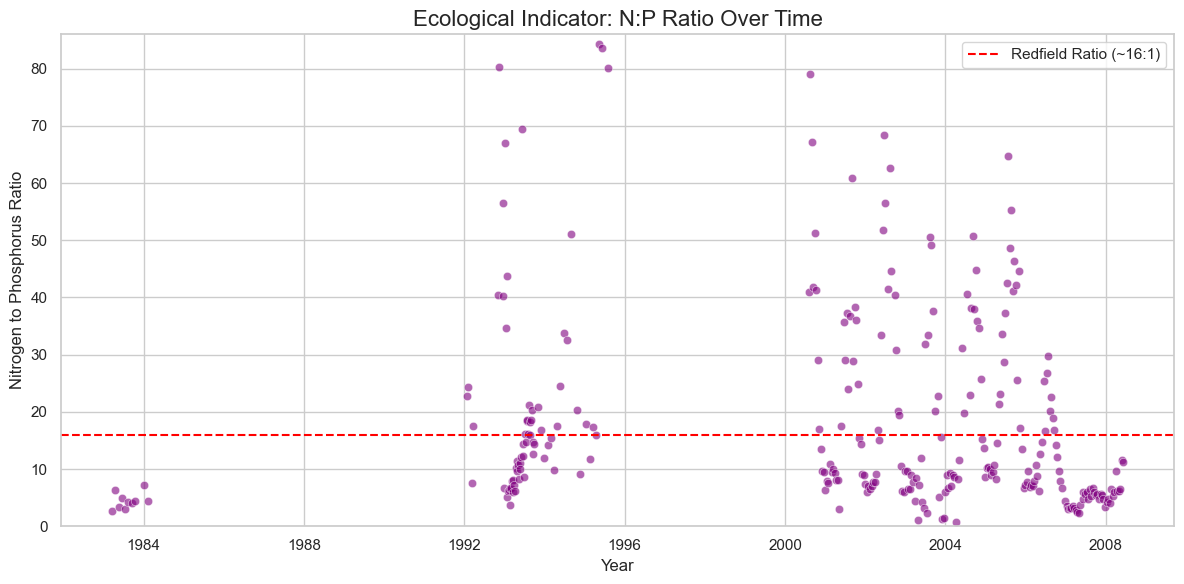

In [18]:
# Calculate the N:P ratio (Nitrate + Ammonia / Phosphate)
# First, ensure we don't divide by zero by dropping rows with zero or NaN phosphates
df_np = df.dropna(subset=['NO3_NO2_N_Diss_Water', 'PO4_P_Diss_Water', 'NH4_N_Diss_Water']).copy()
df_np = df_np[df_np['PO4_P_Diss_Water'] > 0]

# Total available dissolved inorganic nitrogen (DIN) is roughly NO3 + NH4
df_np['Total_Inorganic_N'] = df_np['NO3_NO2_N_Diss_Water'] + df_np['NH4_N_Diss_Water']
df_np['N_P_Ratio'] = df_np['Total_Inorganic_N'] / df_np['PO4_P_Diss_Water']

plt.figure(figsize=(12, 6))

# Plot the ratio over time
sns.scatterplot(data=df_np, x='date_time', y='N_P_Ratio', alpha=0.6, color='purple')
plt.axhline(y=16, color='red', linestyle='--', label='Redfield Ratio (~16:1)')

plt.title('Ecological Indicator: N:P Ratio Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Nitrogen to Phosphorus Ratio', fontsize=12)

# Limit y-axis to avoid extreme outliers skewing the visual
plt.ylim(0, df_np['N_P_Ratio'].quantile(0.95))
plt.legend()
plt.tight_layout()
plt.show()

Conclusion: The N:P ratio is consistently and drastically above the natural Redfield Ratio (16:1), especially after the year 2000. Because the system is overloaded with Nitrogen, Phosphorus is the limiting factor. This means even a tiny addition of phosphorus (e.g., from detergents or sewage) will immediately trigger explosive algal and hyacinth blooms.

## Fresh pollutions vs. old pollution

Our dataset contains both Nitrates (NO3_NO2_N) and Ammonia (NH4_N). This is a goldmine. Ammonia indicates fresh, recent pollution (like a raw sewage spill or a fresh manure runoff). Over time, bacteria convert this into Nitrates (older pollution). Comparing these two shows you if pollution is an ongoing, active spill.

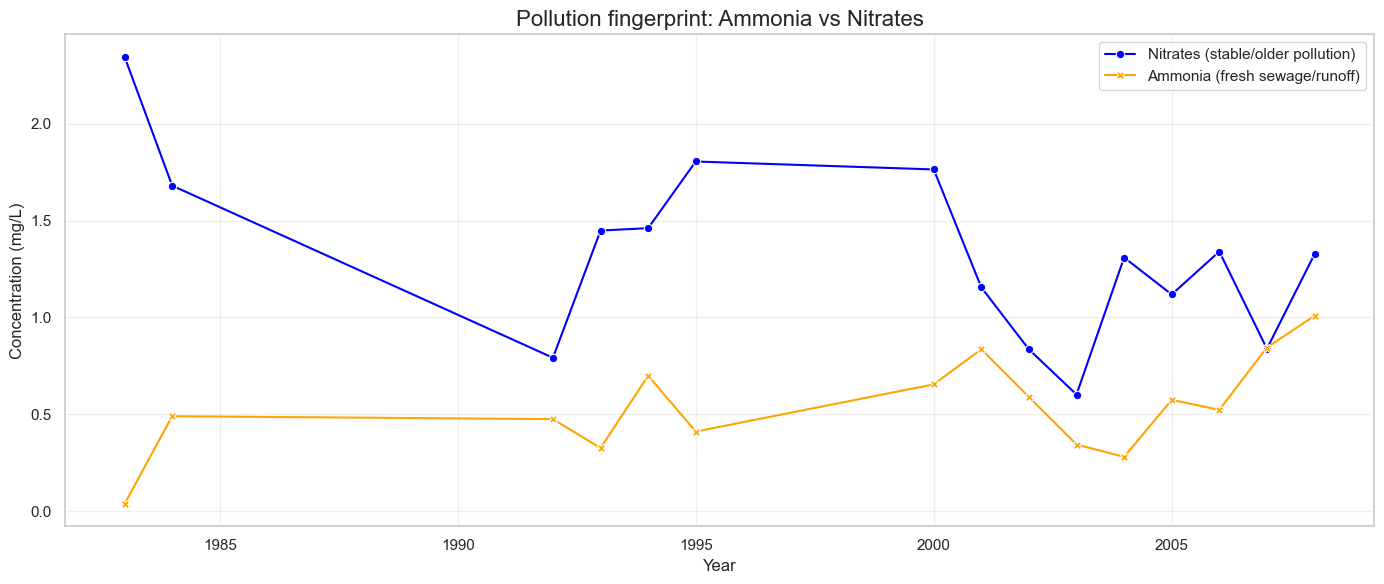

In [19]:
# Group by year to see the trend of both Nitrogen types
df_nitrogen = df.groupby('Year')[['NO3_NO2_N_Diss_Water', 'NH4_N_Diss_Water']].mean().reset_index()

# Filter out years with no data to keep the graph clean
df_nitrogen = df_nitrogen.dropna()

plt.figure(figsize=(14, 6))

# Plot Nitrates (stable/older pollution)
sns.lineplot(data=df_nitrogen, x='Year', y='NO3_NO2_N_Diss_Water', 
             label='Nitrates (stable/older pollution)', marker='o', color='blue')

# Plot Ammonia (fresh/raw pollution)
sns.lineplot(data=df_nitrogen, x='Year', y='NH4_N_Diss_Water', 
             label='Ammonia (fresh sewage/runoff)', marker='X', color='orange')

plt.title('Pollution fingerprint: Ammonia vs Nitrates', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Concentration (mg/L)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Conclusion: The nitrogen profile is heavily dominated by Nitrates rather than Ammonia. This indicates that the pollution is mostly "older" (like agricultural leaching or treated wastewater where ammonia has already oxidized) rather than constant, active dumping of raw, untreated sewage.

## Decadal Shift of the "Baseline" (Violin Plots)
Line charts are great, but violin plots show how the entire distribution of water quality has shifted over the decades. It visually proves that the "normal" state of the river is permanently getting worse

C:\Users\Femke\AppData\Local\Temp\ipykernel_9136\3629932562.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_decades, x='Decade', y='EC_Phys_Water', palette='muted', inner='quartile')


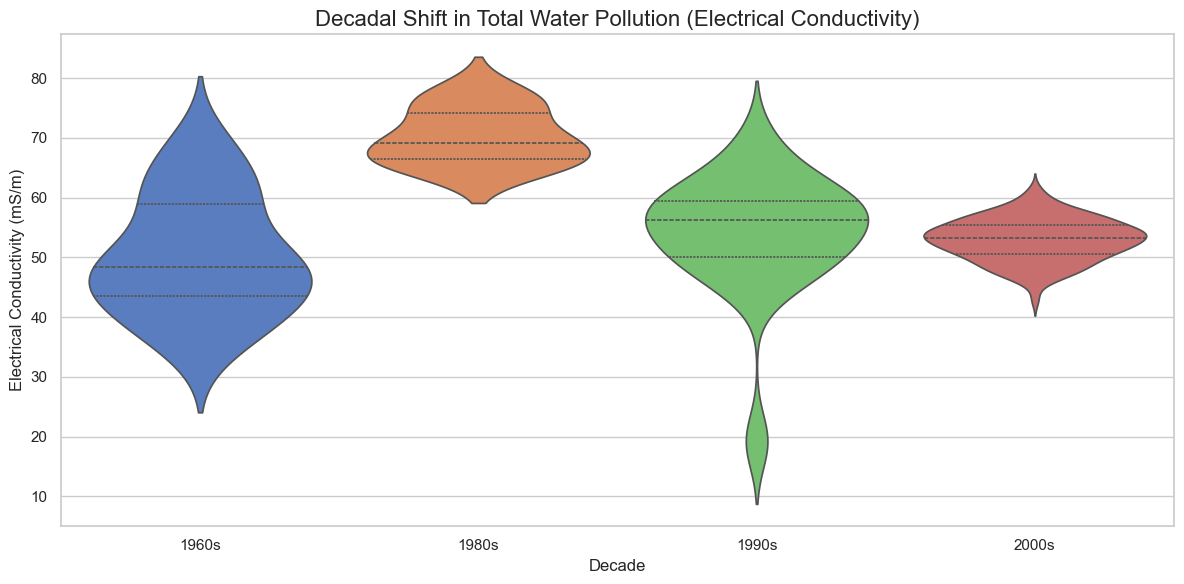

In [20]:
# Create a new column that categorizes data by Decade
df['Decade'] = (df['Year'] // 10) * 10

# Drop empty decades
df_decades = df.dropna(subset=['Decade', 'EC_Phys_Water']).copy()
df_decades['Decade'] = df_decades['Decade'].astype(int).astype(str) + 's'

plt.figure(figsize=(12, 6))

# We use Electrical Conductivity (EC) as a proxy for total dissolved pollutants/salts
sns.violinplot(data=df_decades, x='Decade', y='EC_Phys_Water', palette='muted', inner='quartile')

plt.title('Decadal Shift in Total Water Pollution (Electrical Conductivity)', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Electrical Conductivity (mS/m)', fontsize=12)

plt.tight_layout()
plt.show()

Conclusion: The ecosystem's baseline has permanently shifted. The massive upward jump in Electrical Conductivity during the 2000s proves that the dam is accumulating dissolved pollutants over time and has lost its natural capacity to flush them out. The "new normal" is highly polluted.